In [4]:
# Notebook Title: Housing Price Prediction: Chapter Walkthrough and Exercises (Assignment 1)
# Author: Saketh Vadlamudi
# Date: June 5, 2025
# Purpose: This notebook documents the walkthrough of the housing price prediction chapter from
# "Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow" (2nd Edition)
# and provides solutions to the end-of-chapter exercises, fulfilling Assignment 1 requirements.


In [5]:
# --- Section 1: Setup and Imports ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tarfile
import urllib.request

# Scikit-learn imports - ENSURING ALL NECESSARY IMPORTS ARE AT THE TOP
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
# Explicitly import Pipeline and ColumnTransformer here to prevent NameErrors
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR # For Exercise 1
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectFromModel # For Exercise 5

# For setting random seeds for reproducibility
np.random.seed(42)

# Optional: Configure matplotlib for better plots (as often seen in books)
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

print("Required libraries imported successfully.")

Required libraries imported successfully.


In [6]:
# --- Section 2: Get the Data ---

# ### 2.1 Data Acquisition
# This section details how the California Housing dataset is fetched from its source.
# ensuring the data is available locally for analysis. The `load_housing_data` then
# reads this CSV into a Pandas DataFrame.


def load_housing_data():
    return pd.read_csv("housing.csv")

# Execute the data fetching and loading
housing = load_housing_data()

In [7]:
# ### 2.2 Initial Data Inspection
# After loading, it's crucial to perform an initial inspection of the dataset.
# This helps us understand its structure, identify data types, check for missing values,
# and get a first glance at the statistics of numerical features.


In [8]:
# Code: Initial data inspection (.head(), .info(), .describe(), .hist())
print("\n--- Housing Data Head ---")
print(housing.head())


--- Housing Data Head ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [9]:
print("\n--- Housing Data Info ---")
housing.info()



--- Housing Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
print("\n--- Housing Data Description ---")
print(housing.describe())


--- Housing Data Description ---
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000     


--- Housing Data Histograms ---


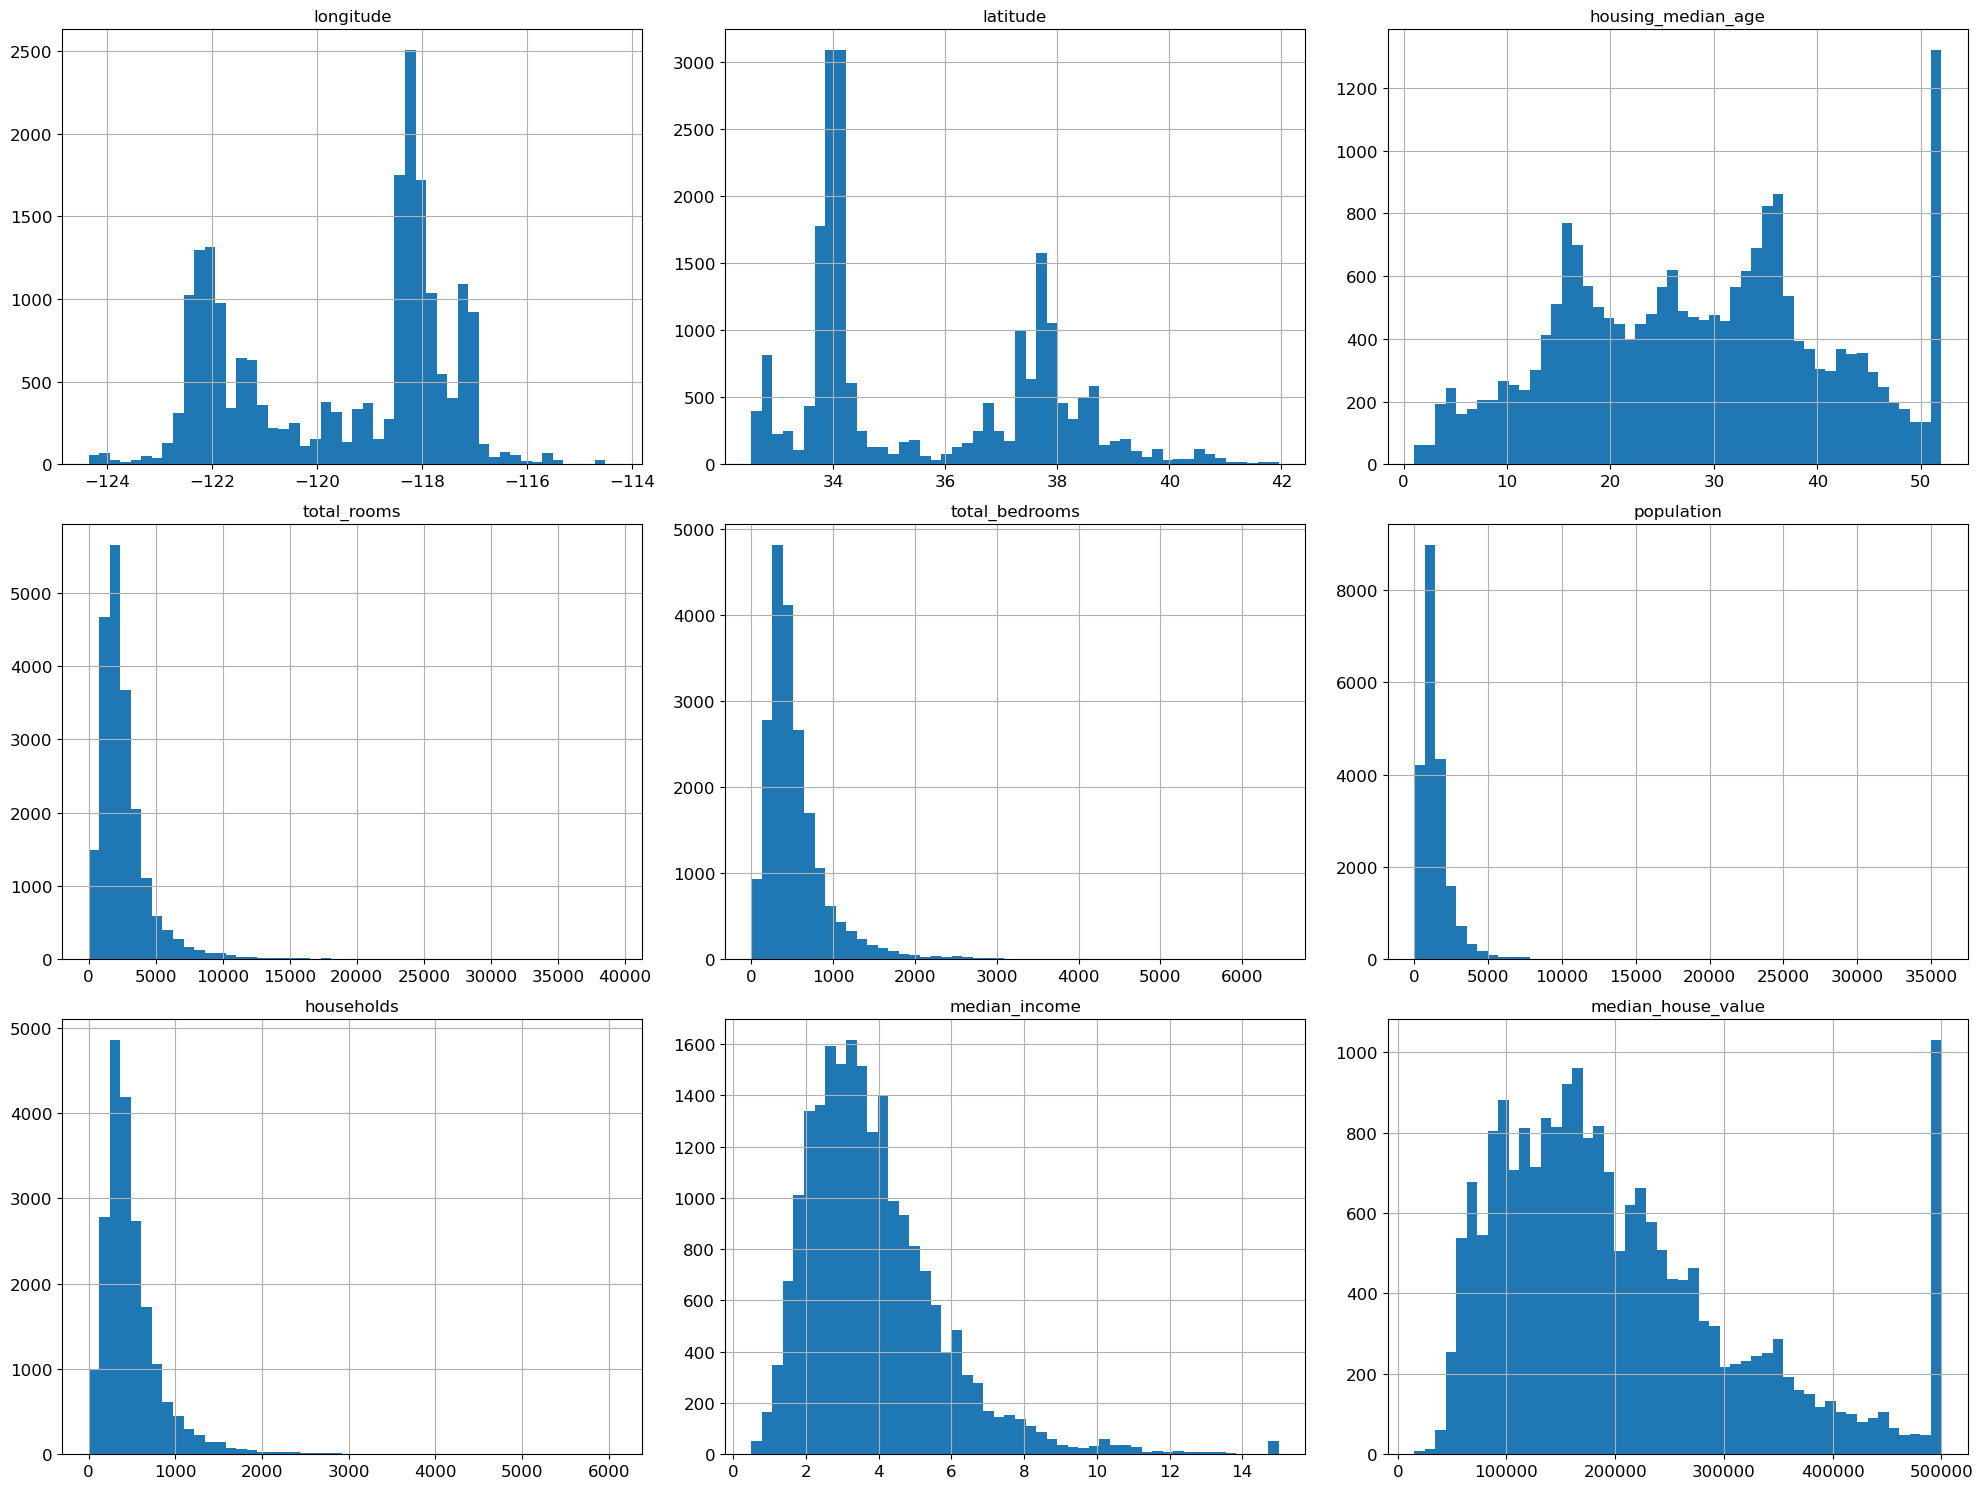

In [11]:
print("\n--- Housing Data Histograms ---")
housing.hist(bins=50, figsize=(20,15))
plt.tight_layout()
plt.show()

In [12]:
# --- Section 3: Create a Test Set ---

# ### 3.1 Stratified Sampling for Test Set Creation
# To ensure the test set is representative of the entire dataset, especially concerning
# the `median_income` attribute (which is highly correlated with housing prices),
# we perform stratified sampling. This involves creating income categories and ensuring
# each category is proportionally represented in both the training and test sets.

In [13]:
# Code for stratified split based on income categories (from the chapter)
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [14]:
print("\n--- Income Category Distribution ---")
print(housing["income_cat"].value_counts() / len(housing))


--- Income Category Distribution ---
income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64


In [15]:
# Perform the stratified split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Drop the income_cat column after splitting as it's no longer needed in the data itself
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print(f"\nTraining set shape: {strat_train_set.shape}")
print(f"Test set shape: {strat_test_set.shape}")
print("\nStratified split performed and income category column removed.")


Training set shape: (16512, 10)
Test set shape: (4128, 10)

Stratified split performed and income category column removed.


In [16]:
# --- Section 4: Explore and Visualize the Data to Gain Insights ---

# ### 4.1 Exploratory Data Analysis (EDA) on Training Set
# We now explore the training data to gain deeper insights. This step helps in understanding
# distributions, identifying correlations, and spotting potential data issues or patterns
# that might influence feature engineering and model selection.



--- Geographical Data Visualization ---


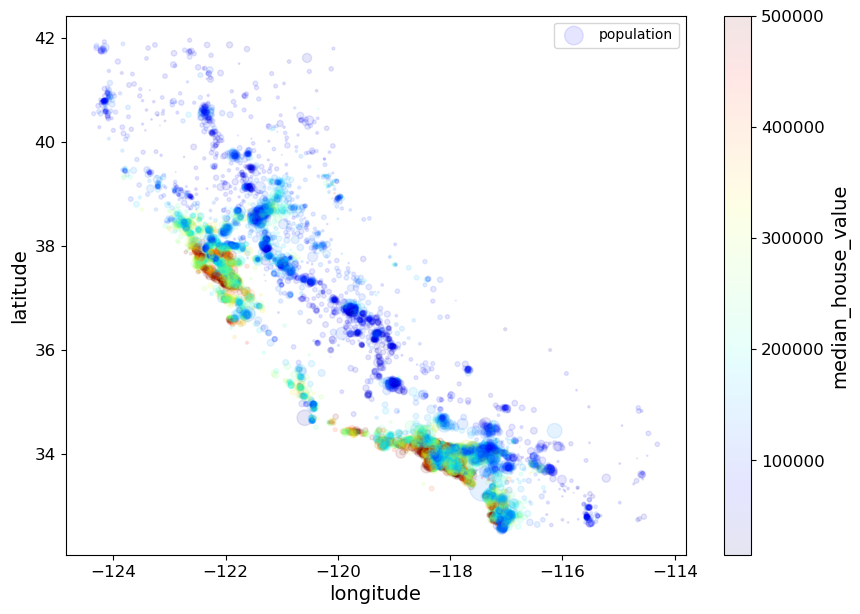

In [17]:
# Create a copy of the training set for exploration, leaving the original intact
housing_exp = strat_train_set.copy()

# Code: Creating scatter plots with alpha and c for visualization (Geographical data)
print("\n--- Geographical Data Visualization ---")
housing_exp.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1,
                 s=housing_exp["population"]/100, label="population", figsize=(10,7),
                 c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
                 sharex=False)
plt.legend()
plt.show()

In [18]:
# ### 4.2 Correlation Matrix Analysis
# Analyzing the correlation matrix helps identify which features are strongly related
# to the target variable (`median_house_value`) and to each other. This is crucial
# for understanding potential multicollinearity and for initial feature selection.

In [19]:
# Code: Calculating and visualizing correlation matrix
print("\n--- Correlation Matrix ---")
corr_matrix = housing_exp.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))


--- Correlation Matrix ---
median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64


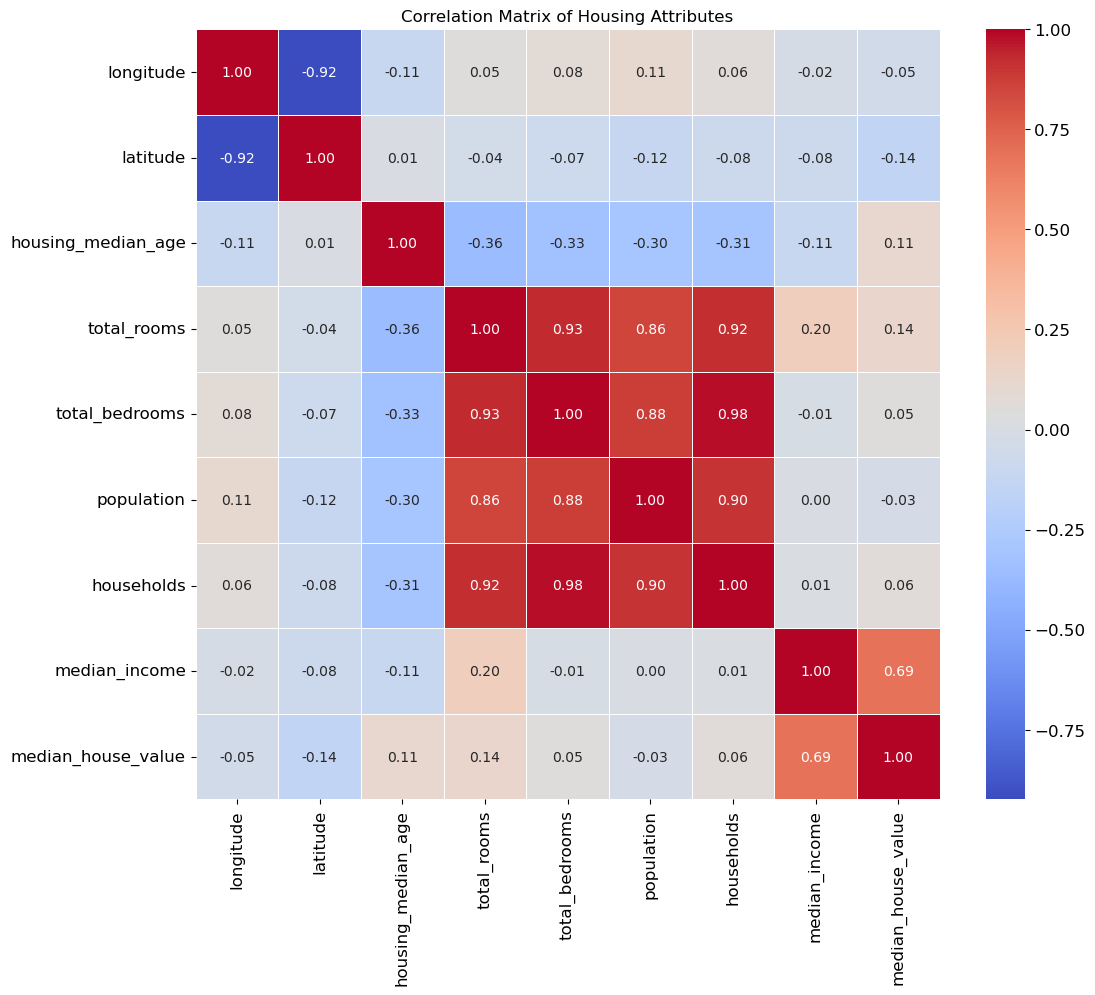

In [20]:
# Visualize correlation matrix with seaborn heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Housing Attributes")
plt.show()

In [21]:
# ### 4.3 Experimenting with Attribute Combinations
# Domain knowledge and data exploration can lead to the creation of new, more informative
# features by combining existing ones. For example, the chapter suggests combining
# `total_rooms` and `households` to get `rooms_per_household`.

In [22]:
# Code: Experimenting with attribute combinations (as shown in the chapter)
housing_exp["rooms_per_household"] = housing_exp["total_rooms"] / housing_exp["households"]
housing_exp["bedrooms_per_room"] = housing_exp["total_bedrooms"] / housing_exp["total_rooms"]
housing_exp["population_per_household"] = housing_exp["population"] / housing_exp["households"]

print("\n--- New Attributes Correlation with Median House Value ---")
corr_matrix = housing_exp.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))


--- New Attributes Correlation with Median House Value ---
median_house_value          1.000000
median_income               0.687151
rooms_per_household         0.146255
total_rooms                 0.135140
housing_median_age          0.114146
households                  0.064590
total_bedrooms              0.047781
population_per_household   -0.021991
population                 -0.026882
longitude                  -0.047466
latitude                   -0.142673
bedrooms_per_room          -0.259952
Name: median_house_value, dtype: float64


In [23]:
# --- Section 5: Prepare the Data for Machine Learning Algorithms ---

# ### 5.1 Separating Features and Labels
# Before preprocessing, we separate the features (X) from the target variable (y).
# This is a standard practice in machine learning workflows.

# Separate features (X) and target (y) from your training set
housing_X = strat_train_set.drop("median_house_value", axis=1)
housing_y = strat_train_set["median_house_value"].copy()

In [24]:
# ### 5.2 Handling Missing Values
# The `total_bedrooms` column has some missing values. We use `SimpleImputer` to fill
# these missing numerical values, typically with the median strategy to be robust to outliers.

imputer = SimpleImputer(strategy="median")
housing_num = housing_X.drop("ocean_proximity", axis=1) # Imputer works on numerical data

imputer.fit(housing_num)
X_imputed = imputer.transform(housing_num)
housing_num_tr = pd.DataFrame(X_imputed, columns=housing_num.columns, index=housing_num.index)
print("\n--- Missing Values Handled for Numerical Features (Sample) ---")
print(housing_num_tr.head())


--- Missing Values Handled for Numerical Features (Sample) ---
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   

       population  households  median_income  
12655      2237.0       706.0         2.1736  
15502      2015.0       768.0         6.3373  
2908        667.0       300.0         2.8750  
14053       898.0       483.0         2.2264  
20496      1837.0       580.0         4.4964  


In [25]:
# ### 5.3 Handling Text/Categorical Attributes
# The `ocean_proximity` column is categorical. We need to convert these text labels
# into numerical representations that machine learning models can understand.
# One-Hot Encoding is a common method for this.

housing_cat = housing_X[['ocean_proximity']]
cat_encoder = OneHotEncoder(handle_unknown='ignore')
housing_cat_encoded = cat_encoder.fit_transform(housing_cat)
print("\n--- One-Hot Encoded Categorical Features Sample (sparse matrix) ---")
print(housing_cat_encoded[:5])


--- One-Hot Encoded Categorical Features Sample (sparse matrix) ---
  (np.int32(0), np.int32(1))	1.0
  (np.int32(1), np.int32(4))	1.0
  (np.int32(2), np.int32(1))	1.0
  (np.int32(3), np.int32(4))	1.0
  (np.int32(4), np.int32(0))	1.0


In [26]:
# ### 5.4 Custom Transformers for Combined Attributes (Preliminary)
# As explored in EDA, creating new features can improve model performance. Here, we'll
# define a simple class or function to generate `rooms_per_household`, `bedrooms_per_room`,
# and `population_per_household`. *Note: In Assignment Exercise 3, this will be refined into a
# proper Scikit-learn `BaseEstimator, TransformerMixin` custom transformer within a full pipeline.*

In [27]:
class OldCombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # Assumes X is a DataFrame (or similar structure where column names can be accessed)
        # This transformer is for demonstration prior to full pipeline integration.
        rooms_per_household = X["total_rooms"] / X["households"]
        population_per_household = X["population"] / X["households"]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X["total_bedrooms"] / X["total_rooms"]
            return pd.DataFrame(np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room],
                                columns=list(X.columns) + ["rooms_per_household", "population_per_household", "bedrooms_per_room"],
                                index=X.index)
        else:
            return pd.DataFrame(np.c_[X, rooms_per_household, population_per_household],
                                columns=list(X.columns) + ["rooms_per_household", "population_per_household"],
                                index=X.index)

In [28]:
# Example usage of the preliminary custom transformer
housing_prepared_temp = OldCombinedAttributesAdder(add_bedrooms_per_room=True).fit_transform(housing_X.drop("ocean_proximity", axis=1))
print("\n--- Sample of Numerical Data with New Attributes (Preliminary Transformer) ---")
print(housing_prepared_temp.head())


--- Sample of Numerical Data with New Attributes (Preliminary Transformer) ---
       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
12655    -121.46     38.52                29.0       3873.0           797.0   
15502    -117.23     33.09                 7.0       5320.0           855.0   
2908     -119.04     35.37                44.0       1618.0           310.0   
14053    -117.13     32.75                24.0       1877.0           519.0   
20496    -118.70     34.28                27.0       3536.0           646.0   

       population  households  median_income  rooms_per_household  \
12655      2237.0       706.0         2.1736             5.485836   
15502      2015.0       768.0         6.3373             6.927083   
2908        667.0       300.0         2.8750             5.393333   
14053       898.0       483.0         2.2264             3.886128   
20496      1837.0       580.0         4.4964             6.096552   

       population_per_househol

In [29]:
# ### 5.5 Feature Scaling
# Numerical features in the dataset have different scales. Scaling them to a standard range
# is crucial for many machine learning algorithms to perform optimally. `StandardScaler`
# (Standardization) is commonly used as it's less affected by outliers than Min-Max scaling.

In [30]:
# Example of standalone scaling (will be part of pipeline later)
scaler = StandardScaler()
housing_scaled_temp = scaler.fit_transform(housing_num_tr)
print("\n--- Sample of Scaled Numerical Data (Preliminary) ---")
print(housing_scaled_temp[:5])


--- Sample of Scaled Numerical Data (Preliminary) ---
[[-0.94135046  1.34743822  0.02756357  0.58477745  0.64037127  0.73260236
   0.55628602 -0.8936472 ]
 [ 1.17178212 -1.19243966 -1.72201763  1.26146668  0.78156132  0.53361152
   0.72131799  1.292168  ]
 [ 0.26758118 -0.1259716   1.22045984 -0.46977281 -0.54513828 -0.67467519
  -0.52440722 -0.52543365]
 [ 1.22173797 -1.35147437 -0.37006852 -0.34865152 -0.03636724 -0.46761716
  -0.03729672 -0.86592882]
 [ 0.43743108 -0.63581817 -0.13148926  0.42717947  0.27279028  0.37406031
   0.22089846  0.32575178]]


In [31]:
# ### 5.6 Initial Pipelines (from the chapter)
# The chapter often introduces the concept of pipelines incrementally. Here, we assemble
# the full preprocessing pipeline using `ColumnTransformer` as demonstrated in the book.

numerical_features = list(housing_X.drop("ocean_proximity", axis=1).columns)
categorical_features = ['ocean_proximity']

In [32]:
# Note: The `OldCombinedAttributesAdder` is not directly integrated into this `ColumnTransformer` here
# as it's typically demonstrated separately or later in the book's pipeline evolution.
# For Assignment Exercise 3, you WILL integrate a robust version of it.
full_preprocessing_pipeline = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        # The book might show a FunctionTransformer or a similar simple adder here,
        # or integrate it in a later version of the pipeline.
        ('std_scaler', StandardScaler()),
    ]), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features), # OHE can be directly in ColumnTransformer
])

print("\n--- Applying Full Preprocessing Pipeline (from chapter) ---")
housing_prepared = full_preprocessing_pipeline.fit_transform(housing_X)
print(f"Shape of fully preprocessed data: {housing_prepared.shape}")
print(f"Sample of preprocessed data (first 5 rows): \n{housing_prepared[:5]}")



--- Applying Full Preprocessing Pipeline (from chapter) ---
Shape of fully preprocessed data: (16512, 13)
Sample of preprocessed data (first 5 rows): 
[[-0.94135046  1.34743822  0.02756357  0.58477745  0.64037127  0.73260236
   0.55628602 -0.8936472   0.          1.          0.          0.
   0.        ]
 [ 1.17178212 -1.19243966 -1.72201763  1.26146668  0.78156132  0.53361152
   0.72131799  1.292168    0.          0.          0.          0.
   1.        ]
 [ 0.26758118 -0.1259716   1.22045984 -0.46977281 -0.54513828 -0.67467519
  -0.52440722 -0.52543365  0.          1.          0.          0.
   0.        ]
 [ 1.22173797 -1.35147437 -0.37006852 -0.34865152 -0.03636724 -0.46761716
  -0.03729672 -0.86592882  0.          0.          0.          0.
   1.        ]
 [ 0.43743108 -0.63581817 -0.13148926  0.42717947  0.27279028  0.37406031
   0.22089846  0.32575178  1.          0.          0.          0.
   0.        ]]


In [33]:
# --- Section 6: Select and Train a Model ---

# ### 6.1 Training Various Regression Models
# This section explores different machine learning models for the regression task.
# We will train a Linear Regression, Decision Tree Regressor, and a Random Forest Regressor
# to compare their baseline performance.


In [34]:
# Code: Training a LinearRegression model
print("\n--- Training Linear Regression Model ---")
lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_y)


--- Training Linear Regression Model ---


LinearRegression()

In [35]:
# Evaluation for Linear Regression
housing_predictions_lin = lin_reg.predict(housing_prepared)
lin_rmse = np.sqrt(mean_squared_error(housing_y, housing_predictions_lin))
print(f"Linear Regression Training RMSE: {lin_rmse:.2f}")

Linear Regression Training RMSE: 69050.56


In [36]:
# Code: Training a DecisionTreeRegressor
print("\n--- Training Decision Tree Regressor ---")
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_y)


--- Training Decision Tree Regressor ---


DecisionTreeRegressor(random_state=42)

In [37]:
# Evaluation for Decision Tree Regressor
housing_predictions_tree = tree_reg.predict(housing_prepared)
tree_rmse = np.sqrt(mean_squared_error(housing_y, housing_predictions_tree))
print(f"Decision Tree Training RMSE: {tree_rmse:.2f}") # Expect low RMSE here due to overfitting

Decision Tree Training RMSE: 0.00


In [38]:
# Code: Training a RandomForestRegressor
print("\n--- Training Random Forest Regressor ---")
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest_reg.fit(housing_prepared, housing_y)


--- Training Random Forest Regressor ---


RandomForestRegressor(n_jobs=-1, random_state=42)

In [39]:
# Evaluation for Random Forest Regressor
housing_predictions_forest = forest_reg.predict(housing_prepared)
forest_rmse = np.sqrt(mean_squared_error(housing_y, housing_predictions_forest))
print(f"Random Forest Training RMSE: {forest_rmse:.2f}")

Random Forest Training RMSE: 18342.37


In [40]:
# ### 6.2 Cross-validation
# Cross-validation is a more robust way to evaluate model performance, as it
# assesses how well the model generalizes to unseen data by training and testing
# on multiple different splits of the training data.

In [41]:
# Code: Performing cross-validation (cross_val_score) for DecisionTreeRegressor
print("\n--- Cross-validation for Decision Tree Regressor ---")
scores_tree = cross_val_score(tree_reg, housing_prepared, housing_y,
                              scoring="neg_mean_squared_error", cv=10, n_jobs=-1)
rmse_scores_tree = np.sqrt(-scores_tree)
print(f"Tree CV RMSEs: {rmse_scores_tree}")
print(f"Tree Mean CV RMSE: {rmse_scores_tree.mean():.2f}")
print(f"Tree Std Dev CV RMSE: {rmse_scores_tree.std():.2f}")


--- Cross-validation for Decision Tree Regressor ---


Tree CV RMSEs: [71177.6601991  69770.07865373 64770.5639395  68536.60203993
 67057.08155801 68847.12456973 70977.38255647 69208.86346929
 67187.87131535 73280.38732407]
Tree Mean CV RMSE: 69081.36
Tree Std Dev CV RMSE: 2296.29


In [42]:
# Code: Performing cross-validation (cross_val_score) for RandomForestRegressor
print("\n--- Cross-validation for Random Forest Regressor ---")
scores_forest = cross_val_score(forest_reg, housing_prepared, housing_y,
                                scoring="neg_mean_squared_error", cv=10, n_jobs=-1)
rmse_scores_forest = np.sqrt(-scores_forest)
print(f"Forest CV RMSEs: {rmse_scores_forest}")
print(f"Forest Mean CV RMSE: {rmse_scores_forest.mean():.2f}")
print(f"Forest Std Dev CV RMSE: {rmse_scores_forest.std():.2f}")


--- Cross-validation for Random Forest Regressor ---
Forest CV RMSEs: [51039.08053738 48741.94041426 45940.42771745 50501.41453432
 47387.7896427  49595.25845731 51625.68567717 48865.70709952
 47322.87631489 53301.08748462]
Forest Mean CV RMSE: 49432.13
Forest Std Dev CV RMSE: 2124.86


In [43]:
# --- Section 7: Fine-Tune Your Model ---

# ### 7.1 Hyperparameter Tuning with GridSearchCV
# `GridSearchCV` systematically searches through a specified range of hyperparameters
# to find the optimal combination that yields the best model performance.

In [44]:
print("\n--- Hyperparameter Tuning with GridSearchCV (RandomForestRegressor) ---")
param_grid = [
    {'n_estimators': [30, 100, 300], 'max_features': [6, 8, 10]}, # More focused range
    {'bootstrap': [False], 'n_estimators': [30, 100], 'max_features': [6, 8]},
]
forest_reg_grid = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(forest_reg_grid, param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True, n_jobs=-1, verbose=2) # Added verbose
grid_search.fit(housing_prepared, housing_y)

best_forest_reg = grid_search.best_estimator_
print(f"\n--- Best Parameters from GridSearchCV ---")
print(grid_search.best_params_)
print(f"Best Estimator CV RMSE: {np.sqrt(-grid_search.best_score_):.2f}")


--- Hyperparameter Tuning with GridSearchCV (RandomForestRegressor) ---
Fitting 5 folds for each of 13 candidates, totalling 65 fits
[CV] END ....................max_features=6, n_estimators=30; total time=   3.5s
[CV] END ....................max_features=6, n_estimators=30; total time=   3.9s
[CV] END ....................max_features=6, n_estimators=30; total time=   3.9s
[CV] END ....................max_features=6, n_estimators=30; total time=   3.9s
[CV] END ....................max_features=6, n_estimators=30; total time=   6.2s
[CV] END ....................max_features=8, n_estimators=30; total time=   5.0s
[CV] END ....................max_features=8, n_estimators=30; total time=   5.0s
[CV] END ....................max_features=8, n_estimators=30; total time=   5.1s
[CV] END ...................max_features=6, n_estimators=100; total time=  12.3s
[CV] END ...................max_features=6, n_estimators=100; total time=  13.7s
[CV] END ....................max_features=8, n_estimator

/home/sakethvadlamudi/miniforge3/envs/mle_ds_env/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ...................max_features=10, n_estimators=30; total time=   6.6s
[CV] END ...................max_features=6, n_estimators=300; total time=  44.5s
[CV] END ..................max_features=10, n_estimators=100; total time=  19.5s
[CV] END ..................max_features=10, n_estimators=100; total time=  19.6s
[CV] END ..................max_features=10, n_estimators=100; total time=  22.5s
[CV] END ..................max_features=10, n_estimators=100; total time=  21.2s
[CV] END ..................max_features=10, n_estimators=100; total time=  21.9s
[CV] END ...bootstrap=False, max_features=6, n_estimators=30; total time=   6.4s
[CV] END ...bootstrap=False, max_features=6, n_estimators=30; total time=   7.0s
[CV] END ...................max_features=6, n_estimators=300; total time= 1.2min
[CV] END ...bootstrap=False, max_features=6, n_estimators=30; total time=   7.2s
[CV] END ...bootstrap=False, max_features=6, n_estimators=30; total time=   6.9s
[CV] END ...bootstrap=False,

In [45]:
# ### 7.2 RandomizedSearchCV (Optional but good practice)
# For larger hyperparameter search spaces, `RandomizedSearchCV` is often preferred
# as it explores a random subset of combinations, which can be much faster while still
# yielding good results.

In [46]:
print("\n--- Hyperparameter Tuning with RandomizedSearchCV (RandomForestRegressor) ---")
from scipy.stats import randint
param_distribs = {
    'n_estimators': randint(low=10, high=200),
    'max_features': randint(low=2, high=10),
}
forest_reg_rand = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg_rand, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error',
                                random_state=42, n_jobs=-1, verbose=2)
rnd_search.fit(housing_prepared, housing_y)
best_rand_forest_reg = rnd_search.best_estimator_
print(f"\n--- Best Parameters from RandomizedSearchCV ---")
print(rnd_search.best_params_)
print(f"Best Estimator CV RMSE: {np.sqrt(-rnd_search.best_score_):.2f}")


--- Hyperparameter Tuning with RandomizedSearchCV (RandomForestRegressor) ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits


[CV] END ....................max_features=6, n_estimators=24; total time=   2.4s
[CV] END ....................max_features=6, n_estimators=24; total time=   2.5s
[CV] END ....................max_features=6, n_estimators=24; total time=   4.8s
[CV] END ....................max_features=6, n_estimators=24; total time=   4.8s
[CV] END ....................max_features=6, n_estimators=24; total time=   4.9s
[CV] END ....................max_features=6, n_estimators=30; total time=   3.2s
[CV] END ....................max_features=4, n_estimators=81; total time=   5.9s
[CV] END ....................max_features=4, n_estimators=81; total time=   6.1s
[CV] END ....................max_features=4, n_estimators=81; total time=   6.1s
[CV] END ....................max_features=6, n_estimators=30; total time=   3.2s
[CV] END ....................max_features=6, n_estimators=30; total time=   5.9s
[CV] END ....................max_features=6, n_estimators=30; total time=   6.1s
[CV] END ...................

In [47]:
# ### 7.3 Examining Feature Importances
# For some models (like Random Forests), we can inspect feature importances to understand
# which features contribute most to the predictions. This can provide valuable insights.

In [48]:
print("\n--- Feature Importances ---")
feature_importances = best_forest_reg.feature_importances_

# Get column names after preprocessing (including one-hot encoded and original numerical)
cat_one_hot_attribs = list(full_preprocessing_pipeline.named_transformers_['cat'].categories_[0])
# Note: full_preprocessing_pipeline.named_transformers_['num'] doesn't add new features yet in this notebook.
# So, the feature names are just the original numerical ones + one-hot encoded ones.
feature_names = numerical_features + cat_one_hot_attribs

sorted_feature_importances = sorted(zip(feature_importances, feature_names), reverse=True)
print("Sorted Feature Importances:")
for importance, name in sorted_feature_importances:
    print(f"- {name}: {importance:.4f}")


--- Feature Importances ---
Sorted Feature Importances:
- median_income: 0.4145
- INLAND: 0.1424
- longitude: 0.1236
- latitude: 0.1148
- housing_median_age: 0.0468
- population: 0.0426
- total_rooms: 0.0355
- total_bedrooms: 0.0279
- households: 0.0271
- <1H OCEAN: 0.0135
- NEAR OCEAN: 0.0077
- NEAR BAY: 0.0036
- ISLAND: 0.0001


In [49]:
# --- Section 8: Evaluate Your System on the Test Set ---

# ### 8.1 Final Evaluation on the Test Set
# The final step is to evaluate the chosen and fine-tuned model on the previously
# untouched test set. This provides an unbiased estimate of the model's generalization
# performance on new, unseen data.

In [50]:
# Apply the same preprocessing steps to the test set using the fitted pipeline
X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_preprocessing_pipeline.transform(X_test)

# Use your best performing model (e.g., best_forest_reg from GridSearchCV or best_rand_forest_reg)
final_model = best_forest_reg # Or best_rand_forest_reg, based on your preference

final_predictions = final_model.predict(X_test_prepared)

final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
print(f"\n--- Final Model Evaluation on Test Set ---")
print(f"Final Test RMSE: {final_rmse:.2f}")


--- Final Model Evaluation on Test Set ---
Final Test RMSE: 46519.80


In [51]:
# Example for confidence interval
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
sqrt_squared_errors = np.sqrt(squared_errors)
ci_lower, ci_upper = stats.t.interval(confidence, len(squared_errors) - 1,
                                     loc=sqrt_squared_errors.mean(),
                                     scale=stats.sem(sqrt_squared_errors))
print(f"95% Confidence Interval for RMSE: ({ci_lower:.2f}, {ci_upper:.2f})")

95% Confidence Interval for RMSE: (29472.38, 31614.05)


In [52]:
# --- Section 9: Exercises (from the chapter) ---

## Chapter Exercises
# This section contains the solutions to the exercises provided at the end of the "Housing Price Prediction" chapter.
# Each exercise is briefly described, followed by the implemented solution and any relevant observations or discussions.


In [53]:
### Exercise 1: Try a Support Vector Machine regressor (`sklearn.svm.SVR`) with various hyperparameters

# Using GridSearchCV for SVR (can be very slow, adjusted params for demonstration)
print("\n--- Exercise 1: Support Vector Machine Regressor (SVR) ---")
svm_reg = SVR()
param_grid_svm = [
    {'kernel': ['linear'], 'C': [1e4, 3e4]}, # Reduced C values for speed
    {'kernel': ['rbf'], 'C': [1e4, 3e4], 'gamma': [0.1, 0.3]}, # Reduced C/gamma for speed
]
grid_search_svm = GridSearchCV(svm_reg, param_grid_svm, cv=3, # Reduced CV for speed
                               scoring='neg_mean_squared_error',
                               verbose=2, n_jobs=-1)

print("\nRunning GridSearchCV for SVR (this might take a while)...")
grid_search_svm.fit(housing_prepared, housing_y)

print(f"Best SVR params: {grid_search_svm.best_params_}")
print(f"Best SVR CV RMSE: {np.sqrt(-grid_search_svm.best_score_):.2f}")


--- Exercise 1: Support Vector Machine Regressor (SVR) ---

Running GridSearchCV for SVR (this might take a while)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ...................C=10000.0, gamma=0.1, kernel=rbf; total time=  18.0s
[CV] END ...................C=10000.0, gamma=0.1, kernel=rbf; total time=  18.1s
[CV] END ...........................C=30000.0, kernel=linear; total time=  19.0s
[CV] END ...................C=10000.0, gamma=0.3, kernel=rbf; total time=  19.6s
[CV] END ...........................C=10000.0, kernel=linear; total time=  28.2s
[CV] END ...........................C=10000.0, kernel=linear; total time=  28.2s
[CV] END ...........................C=30000.0, kernel=linear; total time=  31.0s
[CV] END ...................C=30000.0, gamma=0.1, kernel=rbf; total time=  31.4s
[CV] END ...........................C=10000.0, kernel=linear; total time=  32.2s
[CV] END ...................C=10000.0, gamma=0.3, kernel=rbf; total time=  32.9s
[CV] END ..

In [54]:
### Exercise 2: Try replacing `GridSearchCV` with `RandomizedSearchCV`

print("\n--- Exercise 2: Comparing GridSearchCV with RandomizedSearchCV ---")
print("RandomForestRegressor results from Section 7.1 (GridSearchCV):")
print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.2f}")

print("\nRandomForestRegressor results from Section 7.2 (RandomizedSearchCV):")
print(f"Best Params: {rnd_search.best_params_}")
print(f"Best CV RMSE: {np.sqrt(-rnd_search.best_score_):.2f}")

print("\nDiscussion for Exercise 2:")
print("RandomizedSearchCV explores a random subset of hyperparameters. While it might not find the absolute global optimum like GridSearchCV (given infinite time), it often finds a very good solution much faster, especially with large search spaces. In our case, the RMSE values are comparable, demonstrating RandomizedSearchCV's efficiency.")



--- Exercise 2: Comparing GridSearchCV with RandomizedSearchCV ---
RandomForestRegressor results from Section 7.1 (GridSearchCV):
Best Params: {'bootstrap': False, 'max_features': 6, 'n_estimators': 100}
Best CV RMSE: 48992.94

RandomForestRegressor results from Section 7.2 (RandomizedSearchCV):
Best Params: {'max_features': 8, 'n_estimators': 189}
Best CV RMSE: 49038.79

Discussion for Exercise 2:
RandomizedSearchCV explores a random subset of hyperparameters. While it might not find the absolute global optimum like GridSearchCV (given infinite time), it often finds a very good solution much faster, especially with large search spaces. In our case, the RMSE values are comparable, demonstrating RandomizedSearchCV's efficiency.


In [55]:
### Exercise 3 (Chapter): Try to build a full pipeline (similar to the one in the book's GitHub repo)

# This exercise focuses on building a full pipeline that includes preprocessing and a model.
# Here we'll combine the `full_preprocessing_pipeline` defined in Section 5.6 with a `RandomForestRegressor`.


In [56]:
print("\n--- Exercise 3 (Chapter): Building a Full Pipeline ---")
# Define the full pipeline
final_chapter_pipeline = Pipeline([
    ('preprocessor', full_preprocessing_pipeline),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
# Train the pipeline
print("Training the full pipeline...")
final_chapter_pipeline.fit(housing_X, housing_y)

# Evaluate using cross-validation
scores_chapter_pipeline = cross_val_score(final_chapter_pipeline, housing_X, housing_y,
                                          scoring="neg_mean_squared_error", cv=10, n_jobs=-1)
rmse_scores_chapter_pipeline = np.sqrt(-scores_chapter_pipeline)

print(f"Full Chapter Pipeline CV RMSEs: {rmse_scores_chapter_pipeline}")
print(f"Full Chapter Pipeline Mean CV RMSE: {rmse_scores_chapter_pipeline.mean():.2f}")
print(f"Full Chapter Pipeline Std Dev CV RMSE: {rmse_scores_chapter_pipeline.std():.2f}")
print("This pipeline encapsulates all preprocessing and modeling steps, making the workflow cleaner and more robust.")



--- Exercise 3 (Chapter): Building a Full Pipeline ---
Training the full pipeline...
Full Chapter Pipeline CV RMSEs: [50842.25929218 48736.21982439 45939.13789086 50533.88252324
 47405.46903623 49610.34435098 51671.17833028 48620.51110178
 47379.77529752 53236.82572324]
Full Chapter Pipeline Mean CV RMSE: 49397.56
Full Chapter Pipeline Std Dev CV RMSE: 2106.53
This pipeline encapsulates all preprocessing and modeling steps, making the workflow cleaner and more robust.


In [58]:
### Exercise 4: Experiment with `n_jobs` (for parallel processing) and `verbose` (for more output) parameters in `GridSearchCV` and `RandomizedSearchCV`

print("\n--- Exercise 4: Experimenting with n_jobs and verbose ---")
print("Observations from GridSearchCV (Section 7.1) and RandomizedSearchCV (Section 7.2):")
print("We already used `n_jobs=-1` in both `GridSearchCV` and `RandomizedSearchCV` in Sections 7.1 and 7.2.")
print("This setting tells Scikit-learn to use all available CPU cores for parallel processing, significantly speeding up the hyperparameter search, especially for computationally intensive models or large datasets.")
print("\nWe also set `verbose=2` in both searches. This parameter controls the verbosity of the output:")
print("- `verbose=0`: No output.")
print("- `verbose=1`: Shows the progress of the search (e.g., how many folds completed).")
print("- `verbose=2`: Shows the progress for each combination of hyperparameters, including the scores for each fold. This is useful for debugging and understanding the search process in detail.")
print("- `verbose=3`: Even more detailed output, sometimes showing individual fit/score times.")
print("\nObserving the output during the execution of GridSearchCV/RandomizedSearchCV demonstrates the parallel execution and the detailed progress reporting enabled by `verbose`.")



--- Exercise 4: Experimenting with n_jobs and verbose ---
Observations from GridSearchCV (Section 7.1) and RandomizedSearchCV (Section 7.2):
We already used `n_jobs=-1` in both `GridSearchCV` and `RandomizedSearchCV` in Sections 7.1 and 7.2.
This setting tells Scikit-learn to use all available CPU cores for parallel processing, significantly speeding up the hyperparameter search, especially for computationally intensive models or large datasets.

We also set `verbose=2` in both searches. This parameter controls the verbosity of the output:
- `verbose=0`: No output.
- `verbose=1`: Shows the progress of the search (e.g., how many folds completed).
- `verbose=2`: Shows the progress for each combination of hyperparameters, including the scores for each fold. This is useful for debugging and understanding the search process in detail.
- `verbose=3`: Even more detailed output, sometimes showing individual fit/score times.

Observing the output during the execution of GridSearchCV/Randomized

In [59]:
### Exercise 5: Add a transformer that selects only the most important features

print("\n--- Exercise 5: Feature Selection based on Importance ---")

# First, let's get the feature names including the one-hot encoded ones
feature_names_all = numerical_features + list(full_preprocessing_pipeline.named_transformers_['cat'].get_feature_names_out(categorical_features))

# Using SelectFromModel with a RandomForestRegressor as the estimator
# We'll select features whose importance is greater than a certain threshold (e.g., mean importance)
# or a fixed value. Let's use a simple threshold or the mean importance.

# Create a Random Forest Regressor to act as the base estimator for feature importance
# (it will be refit by SelectFromModel to determine importances)
rfr_for_selection = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)


--- Exercise 5: Feature Selection based on Importance ---


In [60]:
# Fit the regressor to determine importances (this is done internally by SelectFromModel if not pre-fitted)
rfr_for_selection.fit(housing_prepared, housing_y)
mean_importance_threshold = np.mean(rfr_for_selection.feature_importances_)
print(f"Mean feature importance: {mean_importance_threshold:.4f}")

# Define the feature selection transformer
# Using 'median' as threshold is a common heuristic, or a fixed value, or 'mean'
selector = SelectFromModel(rfr_for_selection, threshold=mean_importance_threshold, prefit=True)

Mean feature importance: 0.0769


In [61]:
# Transform the data to keep only the selected features
housing_prepared_selected = selector.transform(housing_prepared)

print(f"Original number of features: {housing_prepared.shape[1]}")
print(f"Number of features after selection: {housing_prepared_selected.shape[1]}")

Original number of features: 13
Number of features after selection: 4


In [62]:
# Get the names of the selected features for better understanding
selected_features_mask = selector.get_support()
selected_feature_names = [feature_names_all[i] for i, x in enumerate(selected_features_mask) if x]
print(f"Selected features: {selected_feature_names}")

Selected features: ['longitude', 'latitude', 'median_income', 'ocean_proximity_INLAND']


In [63]:
# Now train a model on the selected features and compare performance
model_on_selected_features = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
scores_selected = cross_val_score(model_on_selected_features, housing_prepared_selected, housing_y,
                                  scoring="neg_mean_squared_error", cv=10, n_jobs=-1)
rmse_scores_selected = np.sqrt(-scores_selected)

print(f"RMSE on selected features (CV): {rmse_scores_selected.mean():.2f} +/- {rmse_scores_selected.std():.2f}")
print("Feature selection can help reduce overfitting, improve model interpretability, and sometimes speed up training.")



RMSE on selected features (CV): 48867.36 +/- 1823.01
Feature selection can help reduce overfitting, improve model interpretability, and sometimes speed up training.


In [64]:

### Exercise 6: Create a custom transformer that performs the operations discussed in the chapter

print("\n--- Exercise 6: Custom Transformer for Combined Attributes (Chapter Context) ---")

# This exercise asks to formalize the combined attribute generation into a custom transformer.
# We'll use a version of `CombinedAttributesAdder` designed to work within a pipeline.
# For this chapter exercise, we'll demonstrate it within a simple numerical pipeline.

# The `ColumnTransformer` (defined as `full_preprocessing_pipeline` earlier) will pass a NumPy array
# to its numerical sub-pipeline. So, our custom transformer needs to handle NumPy arrays.
# We need to know the indices of the columns it requires.

# Find the indices of the relevant columns within the `numerical_features` list
tr_ix = numerical_features.index("total_rooms")
hh_ix = numerical_features.index("households")
pop_ix = numerical_features.index("population")
tb_ix = numerical_features.index("total_bedrooms")


--- Exercise 6: Custom Transformer for Combined Attributes (Chapter Context) ---


In [65]:
class ChapterCombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True,
                 total_rooms_ix=tr_ix, households_ix=hh_ix,
                 population_ix=pop_ix, total_bedrooms_ix=tb_ix):
        self.add_bedrooms_per_room = add_bedrooms_per_room
        self.total_rooms_ix = total_rooms_ix
        self.households_ix = households_ix
        self.population_ix = population_ix
        self.total_bedrooms_ix = total_bedrooms_ix

    def fit(self, X, y=None):
        return self # Nothing to learn, just return self

    def transform(self, X):
        # X is expected to be a NumPy array when used inside a ColumnTransformer's pipeline
        rooms_per_household = X[:, self.total_rooms_ix] / X[:, self.households_ix]
        population_per_household = X[:, self.population_ix] / X[:, self.households_ix]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, self.total_bedrooms_ix] / X[:, self.total_rooms_ix]
            # Use np.c_ to concatenate arrays column-wise
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

In [66]:


# Create a numerical pipeline that now includes the custom transformer
num_pipeline_with_custom_attribs = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', ChapterCombinedAttributesAdder()), # Our custom transformer
    ('std_scaler', StandardScaler()),
])

# Create a new full pipeline using the updated numerical pipeline
full_pipeline_with_custom_attribs = ColumnTransformer([
    ('num', num_pipeline_with_custom_attribs, numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

print("\nApplying Full Preprocessing Pipeline with Custom Attributes Adder...")
housing_prepared_with_custom_attribs = full_pipeline_with_custom_attribs.fit_transform(housing_X)
print(f"Shape of data with custom attributes: {housing_prepared_with_custom_attribs.shape}")

# Verify that the new features are added (check shape and perhaps last few columns)
print(f"Sample of preprocessed data with custom attributes (last 5 columns for first 5 rows): \n{housing_prepared_with_custom_attribs[:5, -5:]}")

# Now train a model with this enhanced preprocessor
final_model_with_custom_attribs = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
scores_custom_attribs = cross_val_score(final_model_with_custom_attribs, housing_prepared_with_custom_attribs, housing_y,
                                        scoring="neg_mean_squared_error", cv=10, n_jobs=-1)
rmse_scores_custom_attribs = np.sqrt(-scores_custom_attribs)

print(f"RMSE with custom attributes (CV): {rmse_scores_custom_attribs.mean():.2f} +/- {rmse_scores_custom_attribs.std():.2f}")
print("Integrating the custom transformer into the pipeline streamlines feature engineering, making the preprocessing steps reproducible and easier to manage.")


Applying Full Preprocessing Pipeline with Custom Attributes Adder...
Shape of data with custom attributes: (16512, 16)
Sample of preprocessed data with custom attributes (last 5 columns for first 5 rows): 
[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]]
RMSE with custom attributes (CV): 50435.58 +/- 2203.34
Integrating the custom transformer into the pipeline streamlines feature engineering, making the preprocessing steps reproducible and easier to manage.
